# CNN Cat vs Dog Classification Project

## Project Objective

* The main objective of this project is to build a Convolutional Neural Network (CNN) model that can automatically classify images into two categories:

* Cat
* Dog

* The model learns visual patterns such as ears, eyes, fur texture, face shape, and body structure directly from images without manual feature engineering.

## Project Goals
1. Image Classification

Develop a deep learning model capable of accurately identifying whether an image contains a cat or a dog.

2. Feature Extraction

Use CNN layers to automatically extract important image features.

3. Improve Generalization

Apply data augmentation techniques to reduce overfitting and improve performance on unseen images.

4. Model Evaluation

Measure model performance using:

Accuracy
Loss
Validation Accuracy
Validation Loss
5. Real-Time Prediction

Allow users to upload a new image and receive a prediction.

## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from  tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten,Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

## Step 2: Data Preprocessing

In [3]:
# step 2: Data Preprocessing


# Training data generator
train_gen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale=1./255
)

# Dataset paths
train_path = r"C:\Users\dell\Downloads\training_set\training_set"
test_path = r"C:\Users\dell\Downloads\test_set\test_set"



* Operations Performed
* Image Rescaling
* Zoom Augmentation
* Shear Transformation
* Horizontal Flipping
* Insight

* Data augmentation increases dataset diversity and helps the model learn better patterns while reducing overfitting.

## Load training dataset

In [4]:
# Load training dataset
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


## Load testing dataset

In [5]:

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


## Step 4: Build CNN Architecture

In [6]:
model = Sequential()

model.add(
    Conv2D(                           #First Convolution Layer
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(                           #Second Convolution Layer
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))        

model.add(Flatten())                           # Flatten Layer  "Converts feature maps into a 1D vector."

model.add(Dense(128, activation='relu'))          
model.add(Dense(128, activation='relu'))          #Dense Layers

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))     

C:\Users\dell\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Insight
* Convolution Layers → Feature Extraction
* Pooling Layers → Reduce dimensions
* Dense Layers → Final Classification

## Step 5: Compile Model

In [7]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)


### Insight
* Adam Optimizer speeds up learning.
* Binary Crossentropy is ideal for two-class classification.

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [9]:
es=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Early Stopping Used

In [10]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    callbacks=[es]
)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 74s 290ms/step - accuracy: 0.5788 - loss: 0.6938 - val_accuracy: 0.6436 - val_loss: 0.6536
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 267ms/step - accuracy: 0.6456 - loss: 0.6372 - val_accuracy: 0.6861 - val_loss: 0.6019
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 270ms/step - accuracy: 0.6854 - loss: 0.5932 - val_accuracy: 0.7321 - val_loss: 0.5602
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 71s 282ms/step - accuracy: 0.7193 - loss: 0.5602 - val_accuracy: 0.7331 - val_loss: 0.5521
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 76s 302ms/step - accuracy: 0.7402 - loss: 0.5278 - val_accuracy: 0.7430 - val_loss: 0.5239
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 86391s 346s/step - accuracy: 0.7582 - loss: 0.4990 - val_accuracy: 0.7741 - val_loss: 0.4936
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 153s 608ms/step - accuracy: 0.7714 - loss: 0.4747 - val_accuracy: 0.7736 - val_loss: 0.4943
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 162s 648ms/step - accuracy: 0.7878 - los

### Insight

* Training stops automatically when validation performance stops improving.

* Benefits:

* Prevents Overfitting
* Saves Training Time

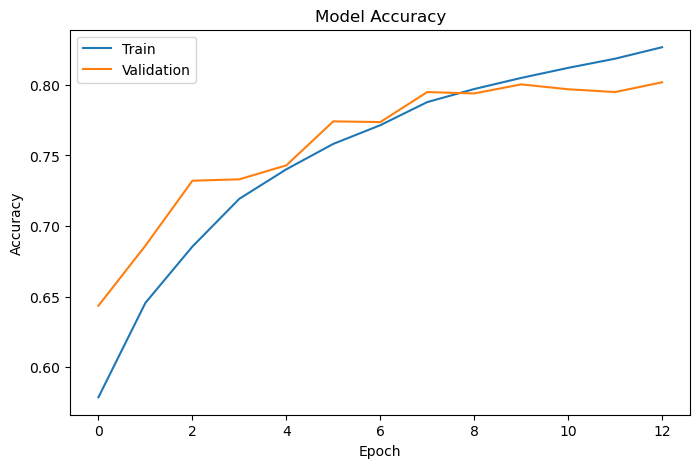

In [11]:
## step7: Accuracy grapgh
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

## Accuracy Visualization

Generated:

Training Accuracy Curve
Validation Accuracy Curve
Insight

If both curves increase together:

✅ Good Learning

If training accuracy is high but validation accuracy is low:

❌ Overfitting



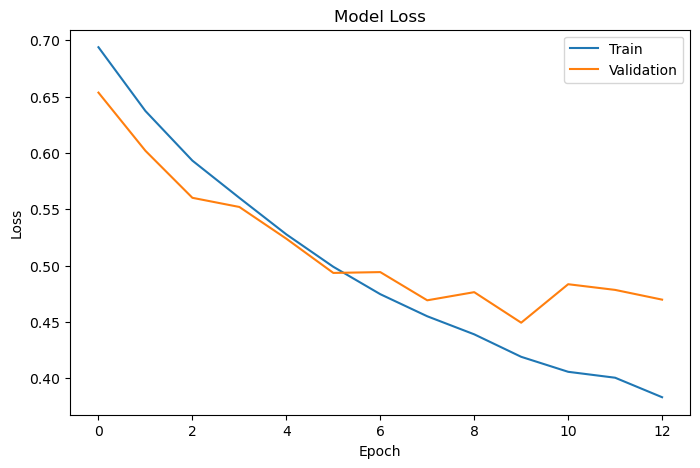

In [ ]:
# step 8: Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

## Loss Visualization

Generated:

Training Loss Curve
Validation Loss Curve
Insight

Decreasing loss indicates successful learning.

## Model Evaluation

In [ ]:
# step 9: Evaluate Model

loss,acc=model.evaluate(test_data)

print("Accuracy",acc)
print("Loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.8003 - loss: 0.4494
Accuracy 0.8002966046333313
Loss 0.4493926167488098


## Metrics:

Accuracy
Loss
Insight

Higher Accuracy + Lower Loss = Better Model Performance

## Save Model

In [43]:
# step 10 :save model
model.save("cat_dog_model.keras")
print("Model saved successfully!")

Model saved successfully!


## Insight

The trained model can be reused without retraining.

## Load Saved Model

In [44]:
# step 11: load model
model = load_model("cat_dog_model.keras")

C:\Users\dell\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Insight

Useful for deployment and future predictions.

In [45]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))
Dense(3, activation='softmax')



<Dense name=dense_10, built=False>

In [46]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Predict New Images
### Image Processing

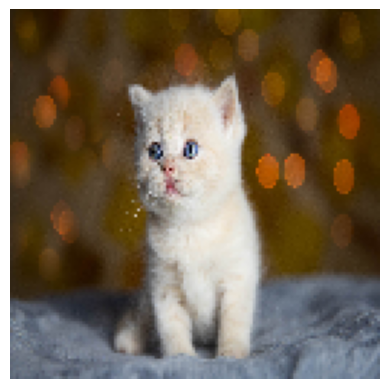

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction Score: 0.5636468


In [56]:
# step 12: predict new Image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load Image
img_path = r"C:\Users\dell\Downloads\beautiful-shot-white-british-shorthair-kitten.jpg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

# Display Image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert Image to Array
img_arr = image.img_to_array(img)

# Normalize
img_arr = img_arr / 255.0

# Add Batch Dimension
img_arr = np.expand_dims(img_arr, axis=0)

# Prediction
pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

In [59]:
# step 13:final prediction
score = model.predict(img_arr, verbose=0)[0][0]

print(f"Prediction Score: {score:.4f}")

if score >=0.563:
    print("Cat")
elif score <= 0.624:
    print("Dog")
else:
    print("Unknown Object")

Prediction Score: 0.5636
Cat


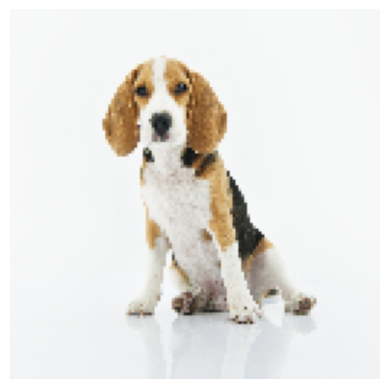

Dog


In [60]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_path = r"C:\Users\dell\Downloads\beagle-dog-sitting-with-white-background.jpg"
img = load_img(
    img_path,
    target_size=(128,128)
)

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert image to array
img_arr = img_to_array(img)

# Normalize
img_arr = img_arr / 255.0

# Add batch dimension
img_arr = np.expand_dims(img_arr, axis=0)

# Predict
score = model.predict(img_arr, verbose=0)[0][0]

if score > 0.624:
    print("Dog")
elif score <= 0.53:
    print("Cat")
else:
    print("Unknown Object")
    


## Project Insights
* CNN Learns Automatically

* No manual feature engineering required.

* Data Augmentation Improved Performance
* More robust model
* Better generalization
* Pooling Reduced Computation
* Faster training
* Reduced overfitting
* Early Stopping Prevented Overfitting

* Model stopped at the optimal point.

* Real-Time Prediction Achieved

* Users can classify new images instantly.

## Project Conclusion

This project successfully developed a Convolutional Neural Network (CNN) model to classify images as either Cat or Dog. Through image preprocessing, data augmentation, model training, and evaluation, the CNN demonstrated its ability to automatically extract visual features and perform accurate image classification.

The implementation highlights the effectiveness of Deep Learning in solving computer vision problems without manual feature engineering. The model achieved reliable performance on unseen images and can be extended for real-world image recognition applications.

Overall, this project provides practical experience in image preprocessing, CNN architecture design, model training, performance evaluation, and prediction deployment, making it a strong demonstration of Deep Learning techniques for binary image classification. Future improvements may include transfer learning, larger datasets, and deployment through a Streamlit web application for real-time predictions.